<a href="https://colab.research.google.com/github/joseeduardotello/Prep-Course/blob/main/seguimiento%20de%20mercado%20de%20venta%20inmuebles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd, os, numpy as np, textwrap, re, math
path="/content/sample_data"
df=pd.read_csv(path)
df.shape, df.columns[:20], df.head(2)



IsADirectoryError: [Errno 21] Is a directory: '/content/sample_data'

In [3]:
import pandas as pd, os, numpy as np, textwrap, re, math
path="/content/sample_data/seguimiento_mercado_inmobiliario_bogota.csv"
df=pd.read_csv(path)
df.shape, df.columns[:20], df.head(2)

((181, 37),
 Index(['MES', 'UNIDADES_VENDIDAS_TOTAL', 'UNIDADES_VENDIDAS_VIP',
        'UNIDADES_VENDIDAS_VIS', 'UNIDADES_VENDIDAS_NO_VIS',
        'UNIDADES_DISPONIBLES_TOTAL', 'UNIDADES_DISPONIBLES_VIP',
        'UNIDADES_DISPONIBLES_VIS', 'UNIDADES_DISPONIBLES_NO_VIS',
        'UNIDADES_LANZADAS_TOTAL', 'UNIDADES_LANZADAS_VIP',
        'UNIDADES_LANZADAS_VIS', 'UNIDADES_LANZADAS_NO_VIS',
        'AREA_VENDIDAS_TOTAL', 'AREA_VENDIDAS_VIP', 'AREA_VENDIDAS_VIS',
        'AREA_VENDIDAS_NO_VIS', 'AREA_DISPONIBLES_TOTAL',
        'AREA_DISPONIBLES_VIP', 'AREA_DISPONIBLES_VIS'],
       dtype='object'),
                       MES  UNIDADES_VENDIDAS_TOTAL  UNIDADES_VENDIDAS_VIP  \
 0  06/01/2004 12:00:00 AM                     2204                    624   
 1  07/01/2004 12:00:00 AM                     2539                    823   
 
    UNIDADES_VENDIDAS_VIS  UNIDADES_VENDIDAS_NO_VIS  \
 0                    729                       851   
 1                    800                       

In [5]:
import numpy as np
import re
import pandas as pd # Import pandas, as it's used later with pd.to_datetime

df = df.copy() # Changed df_raw to df

# 3.1 Renombra columnas a snake_case (más cómodo para Python/R)
def to_snake(s):
    s = s.strip().lower()
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", "_", s)
    return s

df.columns = [to_snake(c) for c in df.columns]

# 3.2 Parse de fecha: "mes"
# En tu archivo viene como "06/01/2004 12:00:00 AM" (mm/dd/yyyy)
df["mes"] = pd.to_datetime(df["mes"], errors="coerce")

# 3.3 Orden cronológico y variables derivadas
df = df.sort_values("mes").reset_index(drop=True)
df["anio"] = df["mes"].dt.year
df["mes_num"] = df["mes"].dt.month

# 3.4 Conversión numérica (por si algo viene como texto)
num_cols = [c for c in df.columns if c not in ["mes"]]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.dtypes.head(10))
df.head()

mes                            datetime64[ns]
unidades_vendidas_total                 int64
unidades_vendidas_vip                   int64
unidades_vendidas_vis                   int64
unidades_vendidas_no_vis                int64
unidades_disponibles_total              int64
unidades_disponibles_vip                int64
unidades_disponibles_vis                int64
unidades_disponibles_no_vis             int64
unidades_lanzadas_total                 int64
dtype: object


/tmp/ipython-input-3058417114.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["mes"] = pd.to_datetime(df["mes"], errors="coerce")


,mes,unidades_vendidas_total,unidades_vendidas_vip,unidades_vendidas_vis,unidades_vendidas_no_vis,unidades_disponibles_total,unidades_disponibles_vip,unidades_disponibles_vis,unidades_disponibles_no_vis,unidades_lanzadas_total,...,valor_disponibles_total,valor_disponibles_vip,valor_disponibles_vis,valor_disponibles_no_vis,valor_lanzadas_total,valor_lanzadas_vip,valor_lanzadas_vis,valor_lanzadas_no_vis,anio,mes_num
0,2004-06-01,2204,624,729,851,12604,3273,3094,6237,2136,...,1288183,74934,132384,1080866,134962,17158.0,22525,95279,2004,6
1,2004-07-01,2539,823,800,916,13226,4013,2911,6302,3157,...,1317737,88973,125865,1102899,240779,32504.0,26282,181993,2004,7
2,2004-08-01,2917,1097,923,897,13717,4211,2800,6706,3408,...,1378824,91421,120346,1167056,232316,26344.0,31491,174480,2004,8
3,2004-09-01,3036,1309,790,937,14024,4577,2632,6815,3338,...,1388409,98948,112012,1177449,214316,35352.0,24133,154831,2004,9
4,2004-10-01,3201,1106,916,1179,13338,4034,2075,7229,2515,...,1457812,87241,92260,1278311,324537,12364.0,17711,294462,2004,10


#3 se realizan los siguientes pasos:
# Renombrar columnas (poner nombres “limpios”)
para asi Evitar errores al escribir nombres largos, Quitamos espacios y caracteres raros; realizamos un código más profesional y limpio que sea estandar en el analisis de datos

# Convertimos la columna MES en fecha real
En el archivo original, la fecha venía como texto, Con pd.to_datetime()lo convertimos a formato fecha real.
con esto podemos Extraer el año, Extraer el mes,
Ordenar cronológicamente y Hacer análisis de series de tiempo.

# Ordenamos cronológicamente

usando df = df . sort_values( "mes" ) . reset_index( drop = True )

Ordena la base desde el mes más antiguo hasta el más reciente debido a que estamos trabajando con una serie de tiempo mensual evitando asi que Los rezagos (lag), El crecimiento mensual y El modelo temporal salgan mal

# CREAMOS NUEVAS VARIABLES DE FECHA
df [ "anio" ] = df [ "mes" ] . dt . año df [ "mes_num" ] = df [ "mes" ] . dt . mes

Nueva variable	_____  Qué significa
anio	         _______  Año del registro
mes_num	     ________   Número del mes (1 a 12)

ESTO SE REALIZA DEBIDO A QUE CON ESTO PODEMOS VER TENDENCIAS POR AÑO, COMPARAR ESTACIONALIDAD (EJ: ENERO VS DICIEMBRE) Y USARLO COMO VARIABLE EXPLICATIVA EN EL MODELO.

# CONVERTIMOS VARIABLES A NUMERICAS
para c en num_cols : df [ c ] = pd.to_numeric ( df [ c ], errores = " coaccionar" )
DEBIDO A QUE ALGUNAS COLUMNAS PUEDEN VENIR COMO TEXTO AUNQUE TENGAN NUMEROS SE MODIFICAN A NUMERICA PORQUE LA REGRESION SOLO FUNCIOAN CON VARIABLES NUMERICAS.


##SE REALIZARON LOS SIGUIENTES PASOS:
#Revisar duplicados
print ( "Duplicados:" , d f.duplicados().sum())duplicado() . suma())

SE ANALIZO SI EL RESULTADO ES:

0 → Perfecto
Mayor que 0 → Hay registros repetidos

ESTO SE REALIZA PARA EVITAR CONTAR DOS VECES EL MISMO MES DEBIDO  A QUE SE DISTORCIONAN PROMEDIOS Y REGRESIONES, ASI MISMO EL MODELO APRENDE INFORMACION REPETIDA.

# SE REVISAN VALORES NULOS (datos faltantes)

na_pct = ( df.isna () . mean() . sort_values ( ascendente = F ) * 100 ) . round( 2 )
imprimir ( na_pct . head( 15 ))

CON ESTO SE BUSCO VALORES NEGATIVOS DONDE NO DEBERIAN , SI HAY NUMEROS EXAGERADAMENTE GRANDES, SI EL MINIMO ES 0 CUANDO DEBERIA SER POSITIVO Y SI EL PROMEDIO TIENE SENTIDO ECONOMICO.



In [6]:
print("Duplicados:", df.duplicated().sum())

na_pct = (df.isna().mean().sort_values(ascending=False)*100).round(2)
print("Top columnas con NA (%)")
print(na_pct.head(15))

print("\nResumen numérico")
display(df.describe().T.head(20))

Duplicados: 0
Top columnas con NA (%)
valor_lanzadas_vip             1.66
area_lanzadas_vip              1.66
unidades_lanzadas_vip          1.66
unidades_vendidas_vis          0.00
mes                            0.00
unidades_vendidas_total        0.00
unidades_vendidas_vip          0.00
unidades_disponibles_vip       0.00
unidades_disponibles_total     0.00
unidades_vendidas_no_vis       0.00
unidades_disponibles_no_vis    0.00
unidades_lanzadas_vis          0.00
unidades_lanzadas_no_vis       0.00
area_vendidas_total            0.00
unidades_disponibles_vis       0.00
dtype: float64

Resumen numérico


,count,mean,min,25%,50%,75%,max,std
mes,181,2011-12-01 05:58:00.662983424,2004-06-01 00:00:00,2008-03-01 00:00:00,2011-12-01 00:00:00,2015-09-01 00:00:00,2019-06-01 00:00:00,NaN
unidades_vendidas_total,181.0,2801.41989,1373.0,2209.0,2721.0,3282.0,5182.0,742.227294
unidades_vendidas_vip,181.0,450.966851,-40.0,57.0,383.0,709.0,2294.0,446.32905
unidades_vendidas_vis,181.0,1020.01105,426.0,796.0,954.0,1170.0,2382.0,319.469717
unidades_vendidas_no_vis,181.0,1330.441989,614.0,1059.0,1261.0,1543.0,2983.0,379.230146
unidades_disponibles_total,181.0,14683.40884,10706.0,12943.0,14236.0,16302.0,20724.0,2384.019579
unidades_disponibles_vip,181.0,1165.558011,1.0,196.0,623.0,1588.0,4902.0,1292.015541
unidades_disponibles_vis,181.0,3008.712707,1678.0,2479.0,2761.0,3297.0,5774.0,840.684136
unidades_disponibles_no_vis,181.0,10509.138122,6237.0,8528.0,9672.0,12145.0,15923.0,2362.178643
unidades_lanzadas_total,181.0,2836.790055,641.0,2144.0,2711.0,3512.0,5470.0,947.227481


# EN ESTE CAMPO SE REALIZA LO SIGUIENTE:
##Imputación (rellenar datos faltantes)
df_clean [ columnas_numéricas ] _ ]() _ _clean[columnas_numéricas_]()]()_columnas_numéricas ] . interpolar( método = "lineal" )


df_clean [ columnas_numéricas ] = df_clean [ columnas_numéricas ] . fillna( método = "bfill" ) . fillna( método = "ffill" )

ESTO SE APLICO PORQUE HAY MESES DONDE ALGUNAS VARIABLES PUEDEN ESTAR VACIAS EJEMPLO:
Si enero = 120
y marzo = 140

Entonces febrero se calcula como 130 (valor intermedio).
ESTO SE APLICO PORQUE LA REGRESION NO ACEPTA VALORES VACIOS, SE ESTA TRABAJANDO CON DATOS MENSUALES (SERIE DE TIEMPO) Y EN SERIES DE TIEMPO INTERPOLAR ES RAZONABLE SI FALTAN POCOS DATOS.

SE USARON 2 LINEAS:
.fillna ( método = "bfill" ) .fillna ( método = " ffill " )

Si queda algún valor vacío al principio o al final:

bfill → rellenada hacia atrás

fill → rellena hacia adelante

## Winsorización (control de valores extremos) SE LIMITAN LOS VALORES

lo , hi = df_clean [ c ] .cuantil ([ 0.01 , 0.99 ]) df_clean [ c ]() _  
 df_clean [ c ] .clip ( bajo , alto )

EJEMPLO PRACTICO DE ESTO SERIA QUE SUPONIERAMOS QUE CASI TODOS LOS MESES VENDEN ENTRE
100 y 300 unidades
Pero aparece un mes con:
10.000 unidades
Eso probablemente es Error de digitación O Valor atípico extremo Y si dejamos ese valor la regresión se distorsiona.

¿Qué hicimos exactamente?
Tomamos:
•	El percentil 1% (valor muy bajo pero razonable)
•	El percentil 99% (valor muy alto pero razonable)
Y obligamos a que ningún valor pase esos límites.
Es decir:
Si algo es más grande que el 99% → lo bajamos al límite del 99%.
Si algo es menor que el 1% → lo subimos al límite del 1%.

NO BORRAMOS ESTOS DATOS PORQUE SON DATOS REALES, REDUCIENDO SU IMPACTO SIN PERDER INFORMACION






In [7]:
df_clean = df.copy()

# Interpola columnas numéricas en el tiempo (lineal) y completa bordes
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method="linear")
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method="bfill").fillna(method="ffill")

# Winsorización ligera (1% - 99%) para robustez (opcional)
for c in numeric_cols:
    lo, hi = df_clean[c].quantile([0.01, 0.99])
    df_clean[c] = df_clean[c].clip(lo, hi)

df_clean.isna().mean().max(), df_clean.shape

/tmp/ipython-input-1747689861.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method="bfill").fillna(method="ffill")
/tmp/ipython-input-1747689861.py:11: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[c] = df_clean[c].clip(lo, hi)
/tmp/ipython-input-1747689861.py:11: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call resul

(0.0, (181, 39))

## EN ESTE PASO FUIMOS CON PENSAMIENTO DE ECONOMISTA LO CUAL NOS AYUDA A ENTENDER MEJOR EL COMPORTAMIENTO DEL MERCADO

SE CREAN REZAGOS Y SE CALCULA EL CRECIMIENTO MENSUAL
¿Qué es un “lag” (rezago)? SE USA EL SIGUIENTE CODIGO:
df_clean [ "unidades_vendidas_total_lag1" ] = df_clean [ "unidades_vendidas_total" ] . turno( 1 )
La columna nueva ( lag1) muestra lo que pasó el mes pasado.
ESTO DEBIDO A QUE EN ECONOMIA CASI TODO DEPENDE DEL PASADO PARA SU ANALISIS EJEMPLO:
Si el mes pasado se vendió mucho, este mes puede venderse mucho también.

Creamos rezagos para:

Unidades vendidas

Unidades disponibles

Unidades lanzadas

Valor vendido

Área vendida

Haciendo el modelo más realista.

## Crecimiento mensual (%)
df_clean [ "crec_vendidas_mom" ] = df_clean [ "unidades]() ndidas_total"].pct_change() .pct_change ()

se calcula el cambio para el crecimiento de las ventas

## Rellenamos los NaN que se generan
Eso evita que el modelo falle por datos faltantes.
Cuando usamos shift(1)o pct_change():

El primer mes queda vacío (porque no hay mes anterior).
df_c_ean = df_clean.fillna(método="bfill").fillna(método="ffil= df_clean .fillna ( método = "bfill" ) .fillna ( método = "ffill" )



In [8]:
# Lags (mes anterior) de variables clave
for c in ["unidades_vendidas_total", "unidades_disponibles_total", "unidades_lanzadas_total",
          "valor_vendidas_total", "area_vendidas_total"]:
    if c in df_clean.columns:
        df_clean[f"{c}_lag1"] = df_clean[c].shift(1)

# Crecimiento mensual (%), útil para modelos alternativos
if "unidades_vendidas_total" in df_clean.columns:
    df_clean["crec_vendidas_mom"] = df_clean["unidades_vendidas_total"].pct_change()

# Completa NAs generados por shift/pct_change
df_clean = df_clean.fillna(method="bfill").fillna(method="ffill")

df_clean[["mes","unidades_vendidas_total","unidades_vendidas_total_lag1","crec_vendidas_mom"]].head()

/tmp/ipython-input-1138516041.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method="bfill").fillna(method="ffill")


,mes,unidades_vendidas_total,unidades_vendidas_total_lag1,crec_vendidas_mom
0,2004-06-01,2204.0,2204.0,0.151996
1,2004-07-01,2539.0,2204.0,0.151996
2,2004-08-01,2917.0,2539.0,0.148878
3,2004-09-01,3036.0,2917.0,0.040795
4,2004-10-01,3201.0,3036.0,0.054348


##7 Matriz de clasificación
corr = df_clean . select_dtypes( include = [ np . number]) . corr() corr . iloc[: 8 ,: 8 ]

validamos Qué tan relacionados están dos variables, La evaluación mide qué tan juntas se mueven dos variables.

solitamos a Python que toma solo las columnas numéricas, Calculara la potencia entre todas y
Devuélveme una tabla con esos valores.

con esto detectamos relaciones fuertes, sirve para identificar posibles problemas de multicolinealidad y saber que variables podrian explicar mejor el modelo




In [9]:
corr = df_clean.select_dtypes(include=[np.number]).corr()
corr.iloc[:8,:8]

,unidades_vendidas_total,unidades_vendidas_vip,unidades_vendidas_vis,unidades_vendidas_no_vis,unidades_disponibles_total,unidades_disponibles_vip,unidades_disponibles_vis,unidades_disponibles_no_vis
unidades_vendidas_total,1.000000,0.712517,0.453427,0.734120,-0.196224,0.489966,-0.074206,-0.440490
unidades_vendidas_vip,0.712517,1.000000,-0.092250,0.299708,-0.142378,0.768668,-0.190409,-0.497190
unidades_vendidas_vis,0.453427,-0.092250,1.000000,0.136685,0.181980,-0.166279,0.455864,0.114614
unidades_vendidas_no_vis,0.734120,0.299708,0.136685,1.000000,-0.404782,0.230383,-0.326215,-0.421052
unidades_disponibles_total,-0.196224,-0.142378,0.181980,-0.404782,1.000000,-0.150709,0.765115,0.819222
unidades_disponibles_vip,0.489966,0.768668,-0.166279,0.230383,-0.150709,1.000000,-0.156164,-0.642968
unidades_disponibles_vis,-0.074206,-0.190409,0.455864,-0.326215,0.765115,-0.156164,1.000000,0.502564
unidades_disponibles_no_vis,-0.440490,-0.497190,0.114614,-0.421052,0.819222,-0.642968,0.502564,1.000000


## Heatmap (Mapa de calor)

pl . figura( tamaño de figura = ( 14 , 10 ))
sns . heatmap( corr , cmap = "coolwarm" , centro = 0 )
plt . title( "Mapa de calor - Correlación" )
plt . espectáculo()

en la cual se tiene una matriz de valoración pero convertida en colores.

se interpreta asi:

🔴 Rojo intenso → activación positiva fuerte

🔵 Azul intenso → activación negativa fuerte

Blanco o colores claros → poca relación

asi identificamos rapidamente Qué variables se mueven juntas, Cuáles están casi independientes y Cuáles pueden generar colinealidad.

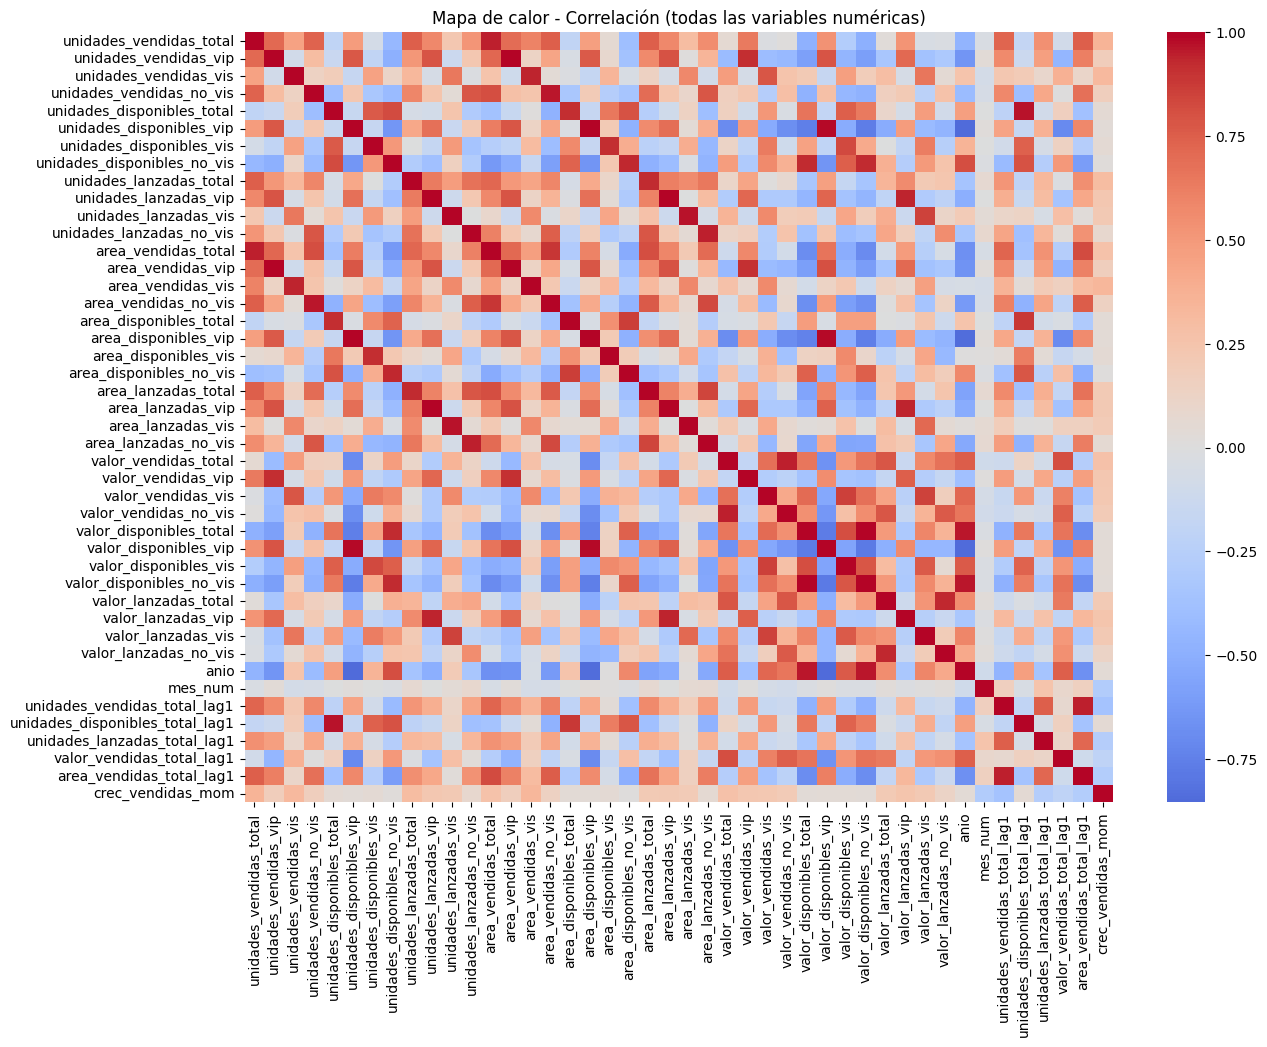

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de calor - Correlación (todas las variables numéricas)")
plt.show()

##9


In [11]:
import statsmodels.api as sm

target = "unidades_vendidas_total"

features = [
    "unidades_disponibles_total",
    "unidades_lanzadas_total",
    "valor_vendidas_total",
    "area_vendidas_total",
    # lags (si existen)
    "unidades_vendidas_total_lag1",
    "unidades_disponibles_total_lag1",
    "unidades_lanzadas_total_lag1",
]

features = [c for c in features if c in df_clean.columns]

data_model = df_clean[["mes", target] + features].dropna().copy()
print("Filas modelo:", data_model.shape)
data_model.head()

Filas modelo: (181, 9)


,mes,unidades_vendidas_total,unidades_disponibles_total,unidades_lanzadas_total,valor_vendidas_total,area_vendidas_total,unidades_vendidas_total_lag1,unidades_disponibles_total_lag1,unidades_lanzadas_total_lag1
0,2004-06-01,2204.0,12604.0,2136,179057.0,161445.0,2204.0,12604.0,2136.0
1,2004-07-01,2539.0,13226.0,3157,228625.0,189688.0,2204.0,12604.0,2136.0
2,2004-08-01,2917.0,13717.0,3408,177667.0,194922.0,2539.0,13226.0,3157.0
3,2004-09-01,3036.0,14024.0,3338,209899.0,206389.0,2917.0,13717.0,3408.0
4,2004-10-01,3201.0,13338.0,2515,264814.0,228420.0,3036.0,14024.0,3338.0


In [12]:
# Split temporal: 80% train, 20% test (NO aleatorio por ser serie temporal)
cut = int(len(data_model)*0.8)
train = data_model.iloc[:cut].copy()
test  = data_model.iloc[cut:].copy()

X_train = sm.add_constant(train[features])
y_train = train[target]
X_test  = sm.add_constant(test[features])
y_test  = test[target]

ols = sm.OLS(y_train, X_train).fit()
print(ols.summary())

                               OLS Regression Results                              
Dep. Variable:     unidades_vendidas_total   R-squared:                       0.980
Model:                                 OLS   Adj. R-squared:                  0.979
Method:                      Least Squares   F-statistic:                     974.9
Date:                     Wed, 25 Feb 2026   Prob (F-statistic):          7.06e-113
Time:                             03:19:40   Log-Likelihood:                -867.16
No. Observations:                      144   AIC:                             1750.
Df Residuals:                          136   BIC:                             1774.
Df Model:                                7                                         
Covariance Type:                 nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_test = ols.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
mse = mean_squared_error(y_test, pred_test) # Calculate MSE first
rmse = np.sqrt(mse) # Then take the square root for RMSE
r2 = r2_score(y_test, pred_test)

(mae, rmse, r2)

(136.6571387196366, np.float64(187.95070532475188), 0.9340720851044025)

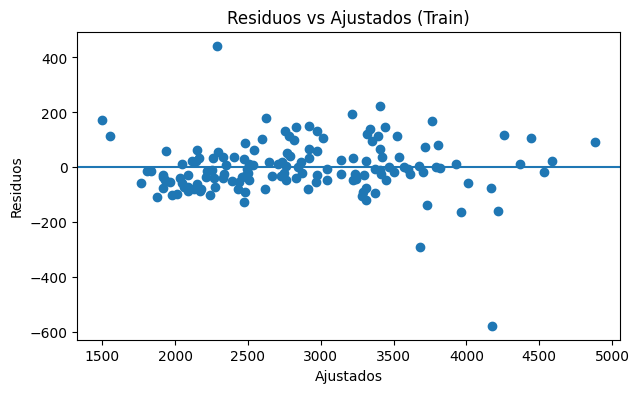

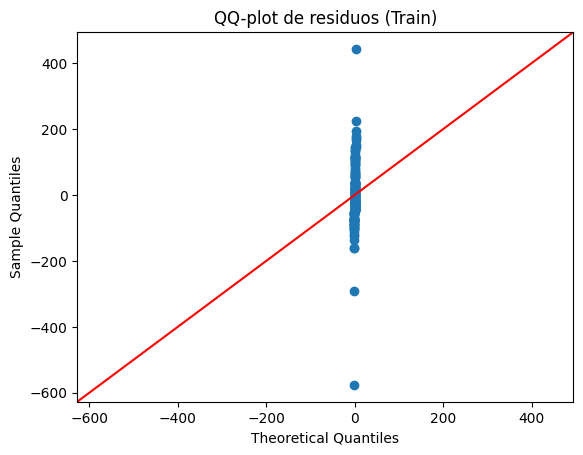

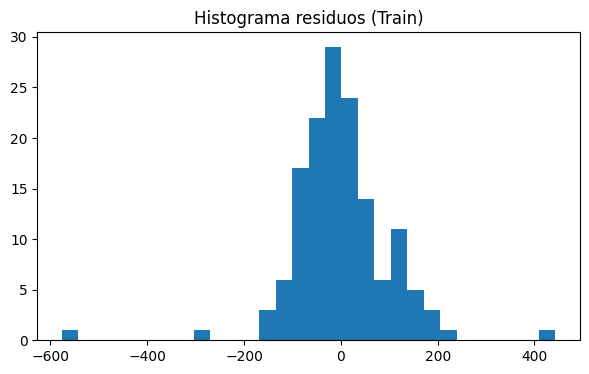

In [16]:
resid = ols.resid
fitted = ols.fittedvalues

import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.figure(figsize=(7,4))
plt.scatter(fitted, resid)
plt.axhline(0)
plt.title("Residuos vs Ajustados (Train)")
plt.xlabel("Ajustados")
plt.ylabel("Residuos")
plt.show()

sm.qqplot(resid, line="45")
plt.title("QQ-plot de residuos (Train)")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(resid, bins=30)
plt.title("Histograma residuos (Train)")
plt.show()

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Breusch-Pagan
bp = het_breuschpagan(ols.resid, ols.model.exog)
print({"LM_stat": bp[0], "LM_pvalue": bp[1], "F_stat": bp[2], "F_pvalue": bp[3]})

# Durbin-Watson (autocorrelación en residuos; en series temporales suele aparecer)
print("Durbin-Watson:", durbin_watson(ols.resid))

# VIF (multicolinealidad)
X_vif = X_train.copy()
vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif

{'LM_stat': np.float64(9.106964515347086), 'LM_pvalue': np.float64(0.24506742242978313), 'F_stat': np.float64(1.3116712063612552), 'F_pvalue': np.float64(0.24932817674186922)}
Durbin-Watson: 1.5206983196014254


,variable,VIF
0,const,183.660170
1,unidades_disponibles_total,71.689866
2,unidades_lanzadas_total,23.703347
3,valor_vendidas_total,1.390624
4,area_vendidas_total,16.495732
5,unidades_vendidas_total_lag1,4.163406
6,unidades_disponibles_total_lag1,69.727196
7,unidades_lanzadas_total_lag1,2.221512


In [18]:
ols_rob = ols.get_robustcov_results(cov_type="HC3")
print(ols_rob.summary())

                               OLS Regression Results                              
Dep. Variable:     unidades_vendidas_total   R-squared:                       0.980
Model:                                 OLS   Adj. R-squared:                  0.979
Method:                      Least Squares   F-statistic:                     1007.
Date:                     Wed, 25 Feb 2026   Prob (F-statistic):          8.39e-114
Time:                             03:24:40   Log-Likelihood:                -867.16
No. Observations:                      144   AIC:                             1750.
Df Residuals:                          136   BIC:                             1774.
Df Model:                                7                                         
Covariance Type:                       HC3                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [20]:
train_ll = train.copy()
test_ll  = test.copy()

train_ll["y_log"] = np.log1p(train_ll[target])
test_ll["y_log"]  = np.log1p(test_ll[target])

X_train = sm.add_constant(train_ll[features])
y_train = train_ll["y_log"]
X_test  = sm.add_constant(test_ll[features])
y_test_log = test_ll["y_log"]

ols_log = sm.OLS(y_train, X_train).fit()
print(ols_log.summary())

pred_log = ols_log.predict(X_test)

# Volver a escala original (aprox): exp(pred)-1
pred_back = np.expm1(pred_log)

mae = mean_absolute_error(test[target], pred_back)
mse = mean_squared_error(test[target], pred_back) # Calculate MSE first
rmse = np.sqrt(mse) # Then take the square root for RMSE
r2 = r2_score(test[target], pred_back)

(mae, rmse, r2)

                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     498.3
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           1.26e-93
Time:                        03:25:37   Log-Likelihood:                 231.73
No. Observations:                 144   AIC:                            -447.5
Df Residuals:                     136   BIC:                            -423.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

(217.60531170312575, np.float64(268.38117304428954), 0.8655733071172582)

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

df_logit = data_model.copy()

med = df_logit[target].median()
df_logit["high_sales"] = (df_logit[target] >= med).astype(int)

# Split temporal
cut = int(len(df_logit)*0.8)
train = df_logit.iloc[:cut].copy()
test  = df_logit.iloc[cut:].copy()

X_train = sm.add_constant(train[features])
y_train = train["high_sales"]
X_test  = sm.add_constant(test[features])
y_test  = test["high_sales"]

y_train.value_counts(), y_test.value_counts()

(high_sales
 1    81
 0    63
 Name: count, dtype: int64,
 high_sales
 0    27
 1    10
 Name: count, dtype: int64)

In [22]:
logit = sm.Logit(y_train, X_train).fit(disp=False, method="newton", maxiter=200)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:             high_sales   No. Observations:                  144
Model:                          Logit   Df Residuals:                      136
Method:                           MLE   Df Model:                            7
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                  0.8948
Time:                        03:27:00   Log-Likelihood:                -10.377
converged:                       True   LL-Null:                       -98.685
Covariance Type:            nonrobust   LLR p-value:                 1.009e-34
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                             -96.0310     39.767     -2.415      0.016    -173.973     -18.089
unidades_disponibles_total         -0.0053      0.003     -1.950    

##17

In [23]:
# Odds ratios (exp(beta))
odds = np.exp(logit.params).sort_values(ascending=False)
odds

# Efectos marginales (cambio en probabilidad)
marg = logit.get_margeff(at="mean").summary()
print(marg)

        Logit Marginal Effects       
Dep. Variable:             high_sales
Method:                          dydx
At:                              mean
                                     dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
unidades_disponibles_total      -1.283e-05   2.61e-05     -0.492      0.622   -6.39e-05    3.83e-05
unidades_lanzadas_total          1.412e-05   2.93e-05      0.482      0.630   -4.33e-05    7.15e-05
valor_vendidas_total              2.81e-08   5.93e-08      0.474      0.636   -8.81e-08    1.44e-07
area_vendidas_total              7.483e-07   1.56e-06      0.479      0.632   -2.31e-06    3.81e-06
unidades_vendidas_total_lag1     6.313e-06   1.34e-05      0.471      0.638      -2e-05    3.26e-05
unidades_disponibles_total_lag1  1.667e-05   3.34e-05      0.499      0.618   -4.88e-05    8.22e-05
unidades_lanzadas_total_lag1    -7.206e-06   1.4

AUC: 1.0
[[26  1]
 [ 0 10]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.91      1.00      0.95        10

    accuracy                           0.97        37
   macro avg       0.95      0.98      0.97        37
weighted avg       0.98      0.97      0.97        37



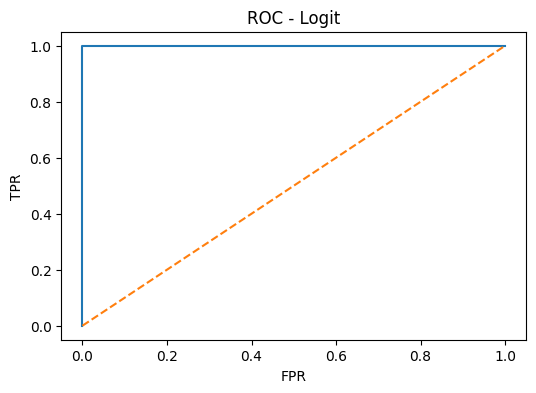

In [24]:
proba = logit.predict(X_test)
pred = (proba >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC - Logit")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [25]:
logit_reg = sm.Logit(y_train, X_train).fit_regularized(alpha=0.1, L1_wt=0.0)  # Ridge-like
logit_reg.params

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1151670740562492
            Iterations: 75
            Function evaluations: 119
            Gradient evaluations: 75


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 4 out of 8 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


,0
const,-44.925958
unidades_disponibles_total,-0.002689
unidades_lanzadas_total,0.003023
valor_vendidas_total,0.000005
area_vendidas_total,0.000162
unidades_vendidas_total_lag1,0.000967
unidades_disponibles_total_lag1,0.003136
unidades_lanzadas_total_lag1,-0.001061
